In [10]:
# 1. Standard Library Imports
import os
import io
import time
import zipfile
import warnings
from random import randint
from pathlib import Path

# 2. Third-Party Data Processing
import pandas as pd
import numpy as np
import requests
import urllib3
from urllib3.util import retry

# 3. Modeling & Machine Learning
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    classification_report, 
    roc_auc_score, 
    precision_recall_curve, 
    confusion_matrix
)
from sklearn.inspection import permutation_importance # Used for feature importance

# 4. Visualization
import matplotlib.pyplot as plt
import seaborn as sns
try:
    import shap # Optional: For advanced interpretability
except ImportError:
    pass

# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
DATA_DIR = Path('Internal data')

In [11]:
# ==============================================================================
# SECTION 1: EXTERNAL DATA ACQUISITION PIPELINE
# ==============================================================================
# API Configuration
if not hasattr(retry.Retry, '_original_init'):
    retry.Retry._original_init = retry.Retry.__init__

def patched_init(self, *args, **kwargs):
    if 'method_whitelist' in kwargs:
        kwargs['allowed_methods'] = kwargs.pop('method_whitelist')
    self._original_init(*args, **kwargs)

retry.Retry.__init__ = patched_init

try:
    from pytrends.request import TrendReq
    PYTRENDS_ACTIVE = True
except ImportError:
    PYTRENDS_ACTIVE = False
    print("  Google Trends library not available, will use simulation mode")

# ==============================================================================
# Health Canada DPD Download
# ==============================================================================
def fetch_health_canada_data(output_dir):
    """Download Health Canada Drug Product Database files"""
    base_url = "https://www.canada.ca/content/dam/hc-sc/migration/hc-sc/dhp-mps/alt_formats/zip/prodpharma/databasdon/"
    targets = {
        "allfiles.zip": ["drug.txt", "ingred.txt", "route.txt", "ther.txt", "schedule.txt"], 
        "allfiles_ia.zip": ["drug_ia.txt", "ingred_ia.txt", "route_ia.txt", "ther_ia.txt", "schedule_ia.txt"]
    }

    print("\n[Pipeline] Health Canada Regulatory Data")
    
    for zip_name, files in targets.items():
        if all((output_dir / f).exists() for f in files):
            print(f"  Local files validated: {zip_name}")
            continue
            
        print(f"  Downloading: {zip_name}")
        try:
            r = requests.get(base_url + zip_name, timeout=30)
            r.raise_for_status()
            with zipfile.ZipFile(io.BytesIO(r.content)) as z:
                for target in files:
                    match = next((f for f in z.namelist() if f.lower() == target.lower()), None)
                    if match: 
                        z.extract(match, output_dir)
            print(f"    Successfully downloaded and extracted")
        except Exception as e:
            print(f"    Warning: Download failed - {e}")

# ==============================================================================
# Google Trends Data Acquisition
# ==============================================================================
def fetch_google_trends_data(output_dir):
    """Acquire Google Trends sentiment data with caching"""
    output_file = output_dir / "ATC_COMPOSITE_TRENDS.csv"
    
    print("\n[Pipeline] Consumer Sentiment Data (Google Trends)")
    
    # Check for existing cached data
    if output_file.exists():
        try:
            existing_data = pd.read_csv(output_file)
            if len(existing_data) > 0 and 'ATC_LEVEL1' in existing_data.columns:
                data_age_days = (pd.Timestamp.now() - pd.to_datetime(existing_data['date']).max()).days
                print(f"  Found cached data (age: {data_age_days} days)")
                print(f"    Records: {len(existing_data):,}")
                print(f"    ATC categories: {existing_data['ATC_LEVEL1'].nunique()}")
                
                if data_age_days < 7:
                    print(f"  Using cached data (sufficiently recent)")
                    return
                else:
                    print(f"  Cached data is {data_age_days} days old, attempting refresh")
        except Exception as e:
            print(f"  Cached file invalid ({e}), will fetch new data")
    
    # Keyword clusters for ATC categories
    ATC_CLUSTERS = {
        'A': ['Stomach pain', 'Ozempic', 'Antacid', 'Digestive health'],
        'B': ['Blood thinner', 'Anticoagulant', 'Blood clot'],
        'C': ['Blood pressure', 'Heart medication', 'Beta blocker'],
        'D': ['Eczema cream', 'Skin rash', 'Cortisone'],
        'G': ['Birth control', 'Hormone replacement', 'Menopause'],
        'H': ['Thyroid medicine', 'Steroids', 'Prednisone'],
        'J': ['Antibiotics', 'Amoxicillin', 'Penicillin', 'Infection med'],
        'L': ['Chemotherapy', 'Cancer treatment', 'Immunotherapy'],
        'M': ['Muscle pain', 'Back pain', 'Arthritis relief'],
        'N': ['Pain killer', 'Tylenol', 'Advil', 'Ibuprofen'],
        'P': ['Lice treatment', 'Worm medicine'],
        'R': ['Cold medicine', 'Cough syrup', 'Flu medicine', 'Inhaler'],
        'S': ['Eye drops', 'Pink eye', 'Ear drops'],
        'V': ['Medical supply', 'First aid'],
        'X': ['Natural remedy', 'Herbal medicine', 'Vitamins'],
        'U': ['Pharmacy shortage', 'Medicine out of stock']
    }

    fetched_data = None

    # Attempt API fetch
    if PYTRENDS_ACTIVE:
        try:
            print("  Connecting to Google Trends API (Canada, 5-year timeframe)")
            pytrends = TrendReq(hl='en-US', tz=360, timeout=(10,25), retries=2, backoff_factor=0.1)
            batch_results = []
            
            for idx, (atc, keywords) in enumerate(ATC_CLUSTERS.items()):
                print(f"    Processing {idx+1}/{len(ATC_CLUSTERS)}: ATC-{atc}")
                try:
                    pytrends.build_payload(keywords, cat=0, timeframe='today 5-y', geo='CA')
                    data = pytrends.interest_over_time()
                    
                    if not data.empty:
                        data = data.drop(columns=['isPartial'], errors='ignore')
                        data['COMPOSITE_INDEX'] = data.max(axis=1)
                        subset = data.reset_index()[['date', 'COMPOSITE_INDEX']]
                        subset['ATC_LEVEL1'] = atc
                        batch_results.append(subset)
                    
                    time.sleep(randint(2, 4))
                except Exception as e:
                    print(f"      Warning: ATC-{atc} failed ({str(e)[:50]})")
                    continue
            
            if batch_results:
                fetched_data = pd.concat(batch_results)
                fetched_data['YEAR_WEEK'] = fetched_data['date'].dt.strftime('%Y%U').astype(int)
                print(f"  API fetch successful: {len(batch_results)} categories retrieved")
                
        except Exception as e:
            print(f"  API connection failed: {e}")

    # Fallback to cached file if API failed
    if fetched_data is None and output_file.exists():
        try:
            fetched_data = pd.read_csv(output_file)
            print(f"  Using cached data as fallback")
        except:
            pass

    # Last resort: Generate simulation data
    if fetched_data is None or fetched_data.empty:
        print("  Generating synthetic sentiment data (simulation mode)")
        dates = pd.date_range(start='2019-01-01', end=pd.Timestamp.now(), freq='W')
        weeks = dates.strftime('%Y%U').astype(int)
        sim_batches = []
        
        for atc in ATC_CLUSTERS.keys():
            signal = np.random.normal(20, 5, size=len(weeks))
            if atc in ['R', 'J', 'N']:  # Respiratory, antibiotics, pain relief show seasonality
                season = 20 * np.sin(2 * np.pi * dates.dayofyear / 365.25 + np.pi/2)
                signal += np.where(season > 5, season, 0)
            
            signal = np.clip(signal, 0, 100)
            df_sim = pd.DataFrame({
                'date': dates, 
                'YEAR_WEEK': weeks, 
                'ATC_LEVEL1': atc, 
                'COMPOSITE_INDEX': signal
            })
            sim_batches.append(df_sim)
        fetched_data = pd.concat(sim_batches)
        print(f"    Generated {len(ATC_CLUSTERS)} synthetic ATC category trends")

    # Save
    fetched_data.to_csv(output_file, index=False)
    print(f"  Data saved: {output_file.name}")

fetch_health_canada_data(DATA_DIR)
fetch_google_trends_data(DATA_DIR)
print("\nExternal data acquisition complete.")


[Pipeline] Health Canada Regulatory Data
  Local files validated: allfiles.zip
  Local files validated: allfiles_ia.zip

[Pipeline] Consumer Sentiment Data (Google Trends)
  Found cached data (age: 4 days)
    Records: 5,856
    ATC categories: 16
  Using cached data (sufficiently recent)

External data acquisition complete.


In [12]:
# ==============================================================================
# SECTION 2: DATA LOADING & PRE-PROCESSING
# ==============================================================================
print("Status: Loading and Cleaning Data...")

def load_csv(filename):
    """Load CSV file from data directory"""
    path = DATA_DIR / filename
    if path.exists():
        return pd.read_csv(path, low_memory=False) 
    else:
        print(f"Warning: File {filename} not found in {DATA_DIR}")
        return pd.DataFrame()

def process_master_dpd():
    """
    Parse Health Canada DPD files to extract regulatory features:
      1. AIG Size (drug substitutability)
      2. ATC Level 1 (therapeutic class)
      3. Route of Administration
      4. Prescription Status
    """
    # Define column schemas for DPD files
    cols_drug = ['DRUG_CODE', 'PROD_CATEG', 'CLASS', 'DIN', 'BRAND_NAME', 'DESCRIPTOR', 'PEDIATRIC_FLAG', 'ACCESSION_NUMBER', 'NUMBER_OF_AIS', 'LAST_UPDATE_DATE', 'AI_GROUP_NO', 'CLASS_F', 'BRAND_NAME_F', 'DESCRIPTOR_F']
    cols_ingred = ['DRUG_CODE', 'ACTIVE_INGREDIENT_CODE', 'INGREDIENT', 'INGREDIENT_SUPPLIED_IND', 'STRENGTH', 'STRENGTH_UNIT', 'STRENGTH_TYPE', 'DOSAGE_VALUE', 'BASE', 'YESNO', 'NOTES', 'INGREDIENT_F', 'STRENGTH_UNIT_F', 'STRENGTH_TYPE_F', 'DOSAGE_VALUE_F']
    cols_route = ['DRUG_CODE', 'ROUTE_OF_ADMINISTRATION_CODE', 'ROUTE_OF_ADMINISTRATION', 'ROUTE_F']
    cols_ther = ['DRUG_CODE', 'TC_ATC_NUMBER', 'TC_ATC', 'TC_ATC_F', 'TC_AHFS_NUMBER', 'TC_AHFS', 'TC_AHFS_F']
    cols_sched = ['DRUG_CODE', 'SCHEDULE', 'SCHEDULE_F']

    def read_stack(f1, f2, cols):
        """Stack active and inactive drug files"""
        dfs = []
        for f in [f1, f2]:
            p = DATA_DIR / f
            if p.exists():
                try: 
                    dfs.append(pd.read_csv(p, names=cols, header=None, quotechar='"', encoding='latin1'))
                except: 
                    continue
        return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

    print("  Processing Health Canada DPD files...")
    df_drug = read_stack("drug.txt", "drug_ia.txt", cols_drug)
    df_ingred = read_stack("ingred.txt", "ingred_ia.txt", cols_ingred)
    df_route = read_stack("route.txt", "route_ia.txt", cols_route)
    df_ther = read_stack("ther.txt", "ther_ia.txt", cols_ther)
    df_sched = read_stack("schedule.txt", "schedule_ia.txt", cols_sched)

    if df_drug.empty: 
        return None

    # Clean DIN numbers and filter to human drugs
    df_drug['DIN'] = pd.to_numeric(df_drug['DIN'], errors='coerce')
    df_drug = df_drug.dropna(subset=['DIN'])
    df_drug['DIN'] = df_drug['DIN'].astype(int)
    df_base = df_drug[df_drug['CLASS'] == 'Human'][['DRUG_CODE', 'DIN', 'AI_GROUP_NO', 'DESCRIPTOR']].copy()

    # Feature 1: AIG Size (number of interchangeable products)
    aig_counts = df_base.groupby('AI_GROUP_NO')['DIN'].nunique().reset_index(name='AIG_SIZE')
    df_base = df_base.merge(aig_counts, on='AI_GROUP_NO', how='left').fillna({'AIG_SIZE': 1})

    # Feature 2: ATC Therapeutic Class (Level 1)
    if not df_ther.empty:
        df_ther['ATC_LEVEL1'] = df_ther['TC_ATC_NUMBER'].astype(str).str[0].str.upper()
        df_ther = df_ther[df_ther['ATC_LEVEL1'].str.isalpha()]
        ther_agg = df_ther.groupby('DRUG_CODE')['ATC_LEVEL1'].first().reset_index()
        df_base = df_base.merge(ther_agg, on='DRUG_CODE', how='left').fillna({'ATC_LEVEL1': 'X'})
    else: 
        df_base['ATC_LEVEL1'] = 'X'

    # Feature 3: Route of Administration
    if not df_route.empty:
        def classify_route(r):
            """Categorize route into major types"""
            r = str(r).upper()
            if any(x in r for x in ['INJECTION', 'INTRAVENOUS', 'PARENTERAL']): 
                return 'INJECTION'
            if any(x in r for x in ['ORAL', 'TABLET', 'CAPSULE']): 
                return 'ORAL'
            if any(x in r for x in ['TOPICAL', 'CREAM', 'OINTMENT']): 
                return 'TOPICAL'
            return 'OTHER'
        
        df_route['ROUTE_CAT'] = df_route['ROUTE_OF_ADMINISTRATION'].apply(classify_route)
        route_agg = df_route.sort_values('ROUTE_CAT').groupby('DRUG_CODE')['ROUTE_CAT'].first().reset_index()
        df_base = df_base.merge(route_agg, on='DRUG_CODE', how='left').fillna({'ROUTE_CAT': 'OTHER'})
    else: 
        df_base['ROUTE_CAT'] = 'OTHER'

    # Feature 4: Prescription Status
    if not df_sched.empty:
        def classify_sched(s):
            """Categorize prescription requirements"""
            s = str(s).upper()
            if 'NARCOTIC' in s or 'CONTROLLED' in s: 
                return 'NARCOTIC'
            if 'SCHEDULE' in s or 'PRESCRIPTION' in s: 
                return 'RX'
            return 'OTC'
        
        df_sched['RX_STATUS'] = df_sched['SCHEDULE'].apply(classify_sched)
        sched_agg = df_sched.sort_values('RX_STATUS').groupby('DRUG_CODE')['RX_STATUS'].first().reset_index()
        df_base = df_base.merge(sched_agg, on='DRUG_CODE', how='left').fillna({'RX_STATUS': 'OTC'})
    else: 
        df_base['RX_STATUS'] = 'OTC'

    # Feature 5: Molecule Name (active ingredient)
    df_ingred['INGREDIENT'] = df_ingred['INGREDIENT'].astype(str).str.lower().str.strip()
    mol_agg = df_ingred.groupby('DRUG_CODE')['INGREDIENT'].apply(
        lambda x: ' / '.join(sorted(set(x)))
    ).reset_index(name='DPD_MOLECULE')
    
    df_base = df_base.merge(mol_agg, on='DRUG_CODE', how='left')
    
    return df_base[['DIN', 'DPD_MOLECULE', 'DESCRIPTOR', 'AIG_SIZE', 'ATC_LEVEL1', 'ROUTE_CAT', 'RX_STATUS']]

# ==============================================================================
# Load Internal McKesson Data
# ==============================================================================
print("  Loading McKesson internal files...")
df_item = load_csv("promitto_item_info_produc_descriptions.csv")
df_supply = load_csv("promitto_actual_drug_shortages.csv")
df_sales = load_csv("promitto_history_product_level_sales_trend_past_year.csv")
df_target = load_csv("promitto_canada_drug_shortage_output.csv")
df_ext_raw = load_csv("Promitto_canada_drug_shortages_raw.csv")

print(f"    Product catalog: {len(df_item):,} rows")
print(f"    Supply data: {len(df_supply):,} rows")
print(f"    Sales data: {len(df_sales):,} rows")
print(f"    Target labels: {len(df_target):,} rows")
print(f"    External reports: {len(df_ext_raw):,} rows")

# Load Health Canada DPD regulatory data
df_dpd = process_master_dpd()
if df_dpd is not None:
    print(f"    DPD regulatory data: {len(df_dpd):,} DINs processed")
else:
    print("    Warning: DPD data not available")

# ==============================================================================
# SECTION 2.1: TIME ALIGNMENT
# ==============================================================================
print("  Aligning time granularities...")

# Convert supply data week format (YYYYWW) to Monday dates
df_supply['date_monday'] = pd.to_datetime(
    df_supply['YEAR_WEEK'].astype(str) + '-1', 
    format='%G%V-%u'
)

# Convert target daily dates to Monday-aligned weeks
df_target['MY_DATE'] = pd.to_datetime(df_target['MY_DATE'])
df_target['date_monday'] = df_target['MY_DATE'] - pd.to_timedelta(
    df_target['MY_DATE'].dt.weekday, 
    unit='D'
)

# Convert sales year-month to first day of month
df_sales['date_month'] = pd.to_datetime(
    df_sales['CAL_YEAR'].astype(str) + '-' + 
    df_sales['CAL_MONTH'].astype(str) + '-01'
)

# Validate time conversions
if df_supply['date_monday'].isnull().any():
    null_count = df_supply['date_monday'].isnull().sum()
    print(f"    Warning: {null_count} YEAR_WEEK values failed to convert")

print(f"    Supply date range: {df_supply['date_monday'].min().date()} to {df_supply['date_monday'].max().date()}")
print(f"    Target date range: {df_target['date_monday'].min().date()} to {df_target['date_monday'].max().date()}")
print(f"    Sales date range: {df_sales['date_month'].min().date()} to {df_sales['date_month'].max().date()}")

# ==============================================================================
# SECTION 2.6: TARGET DATA CLEANING
# ==============================================================================
print("  Cleaning target shortage labels...")

original_count = len(df_target)
print(f"    Original target rows: {original_count:,}")

# Check for data quality issues
empty_molecule = (df_target['MOLECULE_NM'].isna()) | (df_target['MOLECULE_NM'] == '')
empty_count = empty_molecule.sum()

if empty_count > 0:
    print(f"    Found {empty_count:,} rows with empty molecule names")
    print(f"    SHORTAGE_FLAG distribution in empty rows:")
    print(f"      {df_target[empty_molecule]['SHORTAGE_FLAG'].value_counts().to_dict()}")

# Remove invalid rows (no molecule name)
df_target = df_target[
    (df_target['MOLECULE_NM'].notna()) & 
    (df_target['MOLECULE_NM'] != '')
].copy()

cleaned_count = len(df_target)
removed = original_count - cleaned_count

print(f"    Removed {removed:,} invalid rows")
print(f"    Valid shortage events: {cleaned_count:,}")
print(f"    Unique molecules: {df_target['MOLECULE_NM'].nunique()}")
print(f"    Shortage flag distribution:")
print(f"      {df_target['SHORTAGE_FLAG'].value_counts().to_dict()}")

# Validate cleaning results
if cleaned_count == 0:
    raise ValueError("CRITICAL: All target data removed during cleaning. Check MOLECULE_NM column.")

if df_target['SHORTAGE_FLAG'].sum() == 0:
    raise ValueError("CRITICAL: No shortage events (FLAG=1) found in cleaned target data.")

print(f"    Cleaned target date range: {df_target['date_monday'].min().date()} to {df_target['date_monday'].max().date()}")

print("\nStatus: Data loading and preprocessing complete.")

Status: Loading and Cleaning Data...
  Loading McKesson internal files...
    Product catalog: 75,702 rows
    Supply data: 16,284 rows
    Sales data: 96,873 rows
    Target labels: 10,632 rows
    External reports: 21,386 rows
  Processing Health Canada DPD files...
    DPD regulatory data: 38,108 DINs processed
  Aligning time granularities...
    Supply date range: 2023-01-02 to 2023-11-13
    Target date range: 2018-01-01 to 2025-09-29
    Sales date range: 2021-01-01 to 2025-09-01
  Cleaning target shortage labels...
    Original target rows: 10,632
    Found 608 rows with empty molecule names
    SHORTAGE_FLAG distribution in empty rows:
      {0: 608}
    Removed 608 invalid rows
    Valid shortage events: 10,024
    Unique molecules: 9
    Shortage flag distribution:
      {1: 10024}
    Cleaned target date range: 2018-01-01 to 2024-01-29

Status: Data loading and preprocessing complete.


In [47]:
# ==============================================================================
# SECTION 3: FEATURE ENGINEERING PIPELINE 
# ==============================================================================
print("\nStatus: Initiating Feature Engineering...")

# ==============================================================================
# 3.1 MASTER MAPPING & DISPLAY NAME CONSTRUCTION
# ==============================================================================
print("  Building DIN master mapping...")

# Clean item identifiers
df_item['ITEM_NUM_CLEAN'] = df_item['ITEM_NUM'].astype(str).str.replace(r'^I', '', regex=True)
df_item['MFR_ID'] = df_item['VENDOR_NUM'] if 'VENDOR_NUM' in df_item.columns else 0

# Select required columns including product descriptions
target_cols = ['ITEM_NUM_CLEAN', 'DIN_NUM', 'MOLECULE_NM', 'MFR_ID', 'ITEM_CL_GRP_EN_SHORT_DESC']
if 'ITEM_EN_DESC' in df_item.columns:
    target_cols.append('ITEM_EN_DESC')
if 'SHORT_EN_DESC' in df_item.columns:
    target_cols.append('SHORT_EN_DESC')

for col in target_cols:
    if col not in df_item.columns: 
        df_item[col] = np.nan

df_map = df_item[target_cols].copy()

# Clean and validate DIN numbers
df_map['DIN_NUM'] = pd.to_numeric(df_map['DIN_NUM'], errors='coerce')
df_map = df_map.dropna(subset=['DIN_NUM']).astype({'DIN_NUM': int})

# Merge DPD regulatory data if available
if df_dpd is not None:
    df_map = df_map.merge(df_dpd, left_on='DIN_NUM', right_on='DIN', how='left')
    df_map['FINAL_MOLECULE'] = df_map['MOLECULE_NM'].fillna(df_map['DPD_MOLECULE'])
else:
    df_map['FINAL_MOLECULE'] = df_map['MOLECULE_NM']

# Standardize molecule names
df_map['FINAL_MOLECULE'] = df_map['FINAL_MOLECULE'].astype(str).str.lower().str.strip()

# Create human-readable display names for dashboard
print("    Creating display names from internal product catalog...")

def create_display_name(row):
    if 'ITEM_EN_DESC' in row.index and pd.notna(row['ITEM_EN_DESC']) and str(row['ITEM_EN_DESC']).strip() != '':
        desc = str(row['ITEM_EN_DESC']).strip().replace('/ ', '').strip()
        return desc.title()
    
    if 'SHORT_EN_DESC' in row.index and pd.notna(row['SHORT_EN_DESC']) and str(row['SHORT_EN_DESC']).strip() != '':
        desc = str(row['SHORT_EN_DESC']).strip()
        return f"{desc.title()} (DIN: {row['DIN_NUM']})"
    
    molecule = str(row['FINAL_MOLECULE']).title()
    return f"{molecule} (DIN: {row['DIN_NUM']})"

df_map['DRUG_DISPLAY_NAME'] = df_map.apply(create_display_name, axis=1)

# Fill missing regulatory attributes
df_map.fillna({
    'AIG_SIZE': 1, 
    'ATC_LEVEL1': 'X', 
    'ROUTE_CAT': 'OTHER', 
    'RX_STATUS': 'OTC',
    'DRUG_DISPLAY_NAME': 'Unknown Drug'
}, inplace=True)

print(f"    Mapped DINs: {df_map['DIN_NUM'].nunique():,}")
print(f"    Unique molecules: {df_map['FINAL_MOLECULE'].nunique():,}")

# Display sample names
print(f"    Sample display names:")
for name in df_map['DRUG_DISPLAY_NAME'].drop_duplicates().head(3).tolist():
    print(f"      {name}")

# Quality check
total_dins = len(df_map)
using_item_desc = df_map['ITEM_EN_DESC'].notna().sum() if 'ITEM_EN_DESC' in df_map.columns else 0
print(f"    Display name sources:")
print(f"      ITEM_EN_DESC: {using_item_desc:,} ({using_item_desc/total_dins*100:.1f}%)")
print(f"      Fallback: {total_dins - using_item_desc:,}")

# ==============================================================================
# 3.2 SUPPLY CHAIN SIGNALS - ROBUST MULTI-REPRESENTATION
# ==============================================================================
print("  Engineering supply chain features with robust transformations...")

# Map item numbers to DINs
df_supply['ITEM_NUM_CLEAN'] = df_supply['ITEM_NUM'].astype(str).str.replace(r'^I', '', regex=True)
df_supply_merged = df_supply.merge(
    df_map[['ITEM_NUM_CLEAN', 'DIN_NUM']], 
    on='ITEM_NUM_CLEAN', 
    how='inner'
)

print(f"    Supply records mapped: {len(df_supply_merged):,}")
print(f"    Unique DINs with supply data: {df_supply_merged['DIN_NUM'].nunique()}")

# Aggregate to DIN-Week level
df_feat_supply = df_supply_merged.groupby(['DIN_NUM', 'date_monday']).agg({
    'TARGET_RCV_QTY_4_WEEKS': 'sum', 
    'EXP_PO_4_WEEKS': 'sum'
}).reset_index()

print(f"    DIN-Week observations: {len(df_feat_supply):,}")

# Calculate raw supply metrics
df_feat_supply['SUPPLY_GAP_RAW'] = df_feat_supply['EXP_PO_4_WEEKS'] - df_feat_supply['TARGET_RCV_QTY_4_WEEKS']
df_feat_supply['FULFILLMENT_RATIO_RAW'] = df_feat_supply['TARGET_RCV_QTY_4_WEEKS'] / (df_feat_supply['EXP_PO_4_WEEKS'] + 10)

df_feat_supply = df_feat_supply.sort_values(['DIN_NUM', 'date_monday'])

# Apply lag 4 to prevent forward-looking data leakage
print("    Applying lag 4 to prevent forward-looking data leakage...")

df_feat_supply['SUPPLY_GAP_LAG4'] = df_feat_supply.groupby('DIN_NUM')['SUPPLY_GAP_RAW'].shift(4)
df_feat_supply['FULFILLMENT_RATIO_LAG4'] = df_feat_supply.groupby('DIN_NUM')['FULFILLMENT_RATIO_RAW'].shift(4)
df_feat_supply['EXP_PO_LAG4'] = df_feat_supply.groupby('DIN_NUM')['EXP_PO_4_WEEKS'].shift(4)
df_feat_supply['TARGET_RCV_LAG4'] = df_feat_supply.groupby('DIN_NUM')['TARGET_RCV_QTY_4_WEEKS'].shift(4)

# Create trend features
df_feat_supply['SUPPLY_GAP_LAG5'] = df_feat_supply.groupby('DIN_NUM')['SUPPLY_GAP_RAW'].shift(5)
df_feat_supply['SUPPLY_GAP_TREND_RAW'] = df_feat_supply['SUPPLY_GAP_LAG4'] - df_feat_supply['SUPPLY_GAP_LAG5']

df_feat_supply['FULFILLMENT_RATIO_LAG5'] = df_feat_supply.groupby('DIN_NUM')['FULFILLMENT_RATIO_RAW'].shift(5)
df_feat_supply['FULFILLMENT_RATIO_TREND_RAW'] = df_feat_supply['FULFILLMENT_RATIO_LAG4'] - df_feat_supply['FULFILLMENT_RATIO_LAG5']

# Multi-representation strategy
print("    Creating multiple feature representations...")

# Representation 1: Original values (preserve true distribution)
df_feat_supply['SUPPLY_GAP_ORIG'] = df_feat_supply['SUPPLY_GAP_LAG4']
df_feat_supply['FULFILLMENT_RATIO_ORIG'] = df_feat_supply['FULFILLMENT_RATIO_LAG4']
df_feat_supply['SUPPLY_GAP_TREND_ORIG'] = df_feat_supply['SUPPLY_GAP_TREND_RAW']
df_feat_supply['FULFILLMENT_RATIO_TREND_ORIG'] = df_feat_supply['FULFILLMENT_RATIO_TREND_RAW']

# Representation 2: Capped values (prevent extreme data errors)
extreme_cap = {
    'SUPPLY_GAP_LAG4': 100000,
    'SUPPLY_GAP_TREND_RAW': 50000,
    'FULFILLMENT_RATIO_LAG4': 10.0,
    'FULFILLMENT_RATIO_TREND_RAW': 8.0
}

for col, limit in extreme_cap.items():
    if col in df_feat_supply.columns:
        capped_col = f"{col}_CAPPED"
        df_feat_supply[capped_col] = df_feat_supply[col].clip(lower=-limit, upper=limit)
        
        capped_count = ((df_feat_supply[capped_col] == limit) | (df_feat_supply[capped_col] == -limit)).sum()
        if capped_count > 0:
            print(f"      {col}: capped {capped_count} extreme outliers")

# Representation 3: Log transformation (handle skewed distributions)
print("    Applying log transformations...")

for col in ['SUPPLY_GAP_LAG4', 'SUPPLY_GAP_TREND_RAW']:
    if col in df_feat_supply.columns:
        log_col = f"{col}_LOG"
        df_feat_supply[log_col] = np.sign(df_feat_supply[col]) * np.log1p(np.abs(df_feat_supply[col]))

for col in ['FULFILLMENT_RATIO_LAG4', 'FULFILLMENT_RATIO_TREND_RAW']:
    if col in df_feat_supply.columns:
        log_col = f"{col}_LOG"
        safe_values = df_feat_supply[col].clip(lower=0.001)
        df_feat_supply[log_col] = np.log1p(safe_values)

# Representation 4: Categorical indicators (capture extreme events)
print("    Creating categorical shortage indicators...")

df_feat_supply['GAP_SEVERITY'] = pd.cut(
    df_feat_supply['SUPPLY_GAP_LAG4'],
    bins=[-float('inf'), -5000, -1000, -100, 100, 1000, 5000, float('inf')],
    labels=['extreme_shortage', 'severe_shortage', 'moderate_shortage', 'mild_shortage', 
            'balanced', 'mild_surplus', 'large_surplus']
)

df_feat_supply['FULFILLMENT_CRISIS'] = (df_feat_supply['FULFILLMENT_RATIO_LAG4'] < 0.3).astype(int)
df_feat_supply['FULFILLMENT_EXCELLENT'] = (df_feat_supply['FULFILLMENT_RATIO_LAG4'] > 1.5).astype(int)
df_feat_supply['TREND_WORSENING'] = (df_feat_supply['SUPPLY_GAP_TREND_RAW'] < -500).astype(int)
df_feat_supply['TREND_IMPROVING'] = (df_feat_supply['SUPPLY_GAP_TREND_RAW'] > 500).astype(int)

print(f"    Supply features created with lag 4")
print(f"      Original: Preserved true distribution")
print(f"      Capped: Protected against data errors")
print(f"      Log: Handle skewed distributions")
print(f"      Categorical: Capture extreme events")

# Display statistics
print(f"\n    Feature statistics comparison:")
for base_col in ['SUPPLY_GAP_LAG4', 'FULFILLMENT_RATIO_LAG4']:
    if base_col in df_feat_supply.columns:
        orig = df_feat_supply[base_col]
        capped = df_feat_supply[f"{base_col}_CAPPED"]
        
        print(f"\n      {base_col}:")
        print(f"        Original: Min={orig.min():.1f}, Max={orig.max():.1f}, Std={orig.std():.1f}")
        print(f"        Capped:   Min={capped.min():.1f}, Max={capped.max():.1f}, Std={capped.std():.1f}")
        print(f"        Changed: {((orig != capped).sum() / len(orig) * 100):.2f}%")

# ==============================================================================
# 3.3 MARKET STRUCTURE - STATIC MOLECULE-LEVEL FEATURES
# ==============================================================================
print("  Analyzing market structure...")

# Count manufacturers per molecule
market_counts_agg = df_map.groupby('FINAL_MOLECULE')['MFR_ID'].nunique().reset_index(name='NUM_Manufacturer')
market_counts_agg['IS_SOLE_SOURCE'] = (market_counts_agg['NUM_Manufacturer'] == 1).astype(int)

# Map to DIN level
market_counts = df_map[['DIN_NUM', 'FINAL_MOLECULE']].drop_duplicates().merge(
    market_counts_agg, on='FINAL_MOLECULE', how='left'
)

sole_source_count = market_counts_agg['IS_SOLE_SOURCE'].sum()
print(f"    DINs mapped: {len(market_counts):,}")
print(f"    Sole-source molecules: {sole_source_count}")

# ==============================================================================
# 3.4 SALES FEATURES - LAG 1 FOR HISTORICAL DATA
# ==============================================================================
print("  Engineering sales features...")

# Normalize class descriptions
df_sales['CLASS_NORM'] = df_sales['CLASS_DESC'].str.upper().str.strip()
class_counts = df_map.groupby('ITEM_CL_GRP_EN_SHORT_DESC')['DIN_NUM'].nunique().reset_index(name='ITEMS_IN_CLASS')
class_counts['CLASS_NORM'] = class_counts['ITEM_CL_GRP_EN_SHORT_DESC'].astype(str).str.upper().str.strip()

# Aggregate by class and month
df_sales_fix = df_sales.groupby(['CLASS_NORM', 'date_month'])['Sales'].sum().reset_index()
df_sales_fix = df_sales_fix.sort_values(['CLASS_NORM', 'date_month'])

# Apply lag 1: sales are historical, no forward component
print("    Applying lag 1 to sales features...")
df_sales_fix['SALES_LAG1'] = df_sales_fix.groupby('CLASS_NORM')['Sales'].shift(1)

# Calculate weekly estimates and volatility
df_sales_fix = df_sales_fix.merge(class_counts[['CLASS_NORM', 'ITEMS_IN_CLASS']], on='CLASS_NORM', how='left')
df_sales_fix['EST_WEEKLY_SALES_LAG1'] = (df_sales_fix['SALES_LAG1'] / df_sales_fix['ITEMS_IN_CLASS'].replace(0, 1)) / 4
df_sales_fix['SALES_VOLATILITY_LAG1'] = df_sales_fix.groupby('CLASS_NORM')['EST_WEEKLY_SALES_LAG1'].transform(
    lambda x: x.rolling(3, min_periods=1).std()
).fillna(0)

print(f"    Sales features created with lag 1")
print(f"    Unique product classes: {df_sales_fix['CLASS_NORM'].nunique()}")

print("\nStatus: Feature Engineering complete.")


Status: Initiating Feature Engineering...
  Building DIN master mapping...
    Creating display names from internal product catalog...
    Mapped DINs: 16,859
    Unique molecules: 3,373
    Sample display names:
      Levetiracetam Tb 250Mg 100
      Levetiracetam Tb 500Mg 100
      Levetiracetam Tb 750Mg 100
    Display name sources:
      ITEM_EN_DESC: 44,647 (100.0%)
      Fallback: 0
  Engineering supply chain features with robust transformations...
    Supply records mapped: 16,146
    Unique DINs with supply data: 208
    DIN-Week observations: 9,568
    Applying lag 4 to prevent forward-looking data leakage...
    Creating multiple feature representations...
      SUPPLY_GAP_LAG4: capped 1 extreme outliers
      SUPPLY_GAP_TREND_RAW: capped 23 extreme outliers
      FULFILLMENT_RATIO_LAG4: capped 129 extreme outliers
      FULFILLMENT_RATIO_TREND_RAW: capped 289 extreme outliers
    Applying log transformations...
    Creating categorical shortage indicators...
    Supply feat

In [51]:
# ==============================================================================
# SECTION 4: MASTER DATASET CONSTRUCTION
# ==============================================================================
print("\nStatus: Constructing Master Dataset...")

# ==============================================================================
# 4.0 TIME WINDOW ALIGNMENT
# ==============================================================================
print("  Aligning data sources to common time window...")

supply_min, supply_max = df_feat_supply['date_monday'].min(), df_feat_supply['date_monday'].max()
target_min, target_max = df_target['date_monday'].min(), df_target['date_monday'].max()

print(f"    Supply range: {supply_min.date()} to {supply_max.date()}")
print(f"    Target range: {target_min.date()} to {target_max.date()}")

# Use intersection of available data
common_start = max(supply_min, target_min)
common_end = min(supply_max, target_max, pd.Timestamp.now())

print(f"    Common window: {common_start.date()} to {common_end.date()}")

# Filter to common window
df_feat_supply = df_feat_supply[
    (df_feat_supply['date_monday'] >= common_start) & 
    (df_feat_supply['date_monday'] <= common_end)
]

df_target = df_target[
    (df_target['date_monday'] >= common_start) & 
    (df_target['date_monday'] <= common_end)
]

valid_weeks = sorted(df_feat_supply['date_monday'].unique())
print(f"    Final dataset spans {len(valid_weeks)} weeks")

# ==============================================================================
# 4.1 BACKBONE CONSTRUCTION
# ==============================================================================
print("  Building dataset backbone...")

# Create DIN master with metadata
df_backbone = df_map[[
    'DIN_NUM', 'DRUG_DISPLAY_NAME', 'FINAL_MOLECULE',
    'MFR_ID', 'ITEM_CL_GRP_EN_SHORT_DESC', 
    'AIG_SIZE', 'ATC_LEVEL1', 'ROUTE_CAT', 'RX_STATUS'
]].drop_duplicates(subset=['DIN_NUM'])

print(f"    Unique DINs: {len(df_backbone):,}")

# Create DIN x Week cartesian product
df_weeks = pd.DataFrame({'date_monday': valid_weeks})
df_model = df_backbone.merge(df_weeks, how='cross')

print(f"    DIN-Week observations: {len(df_model):,}")
print(f"    Structure: {len(df_backbone):,} DINs x {len(valid_weeks)} weeks")

# ==============================================================================
# 4.2 MERGE SUPPLY FEATURES - ALL REPRESENTATIONS
# ==============================================================================
print("  Merging supply chain features...")

# Select all supply feature representations
supply_cols = ['DIN_NUM', 'date_monday']

# Original values
supply_cols += [
    'SUPPLY_GAP_ORIG', 'FULFILLMENT_RATIO_ORIG',
    'SUPPLY_GAP_TREND_ORIG', 'FULFILLMENT_RATIO_TREND_ORIG',
    'EXP_PO_LAG4', 'TARGET_RCV_LAG4'
]

# Capped values
supply_cols += [
    'SUPPLY_GAP_LAG4_CAPPED', 'FULFILLMENT_RATIO_LAG4_CAPPED',
    'SUPPLY_GAP_TREND_RAW_CAPPED', 'FULFILLMENT_RATIO_TREND_RAW_CAPPED'
]

# Log transformed
supply_cols += [
    'SUPPLY_GAP_LAG4_LOG', 'FULFILLMENT_RATIO_LAG4_LOG',
    'SUPPLY_GAP_TREND_RAW_LOG', 'FULFILLMENT_RATIO_TREND_RAW_LOG'
]

# Categorical indicators
supply_cols += [
    'GAP_SEVERITY', 'FULFILLMENT_CRISIS', 'FULFILLMENT_EXCELLENT',
    'TREND_WORSENING', 'TREND_IMPROVING'
]

# Only keep columns that exist
supply_cols = [col for col in supply_cols if col in df_feat_supply.columns]

df_model = df_model.merge(
    df_feat_supply[supply_cols], 
    on=['DIN_NUM', 'date_monday'], 
    how='left'
)

supply_coverage = df_model['SUPPLY_GAP_ORIG'].notna().sum() / len(df_model) * 100
print(f"    Supply coverage: {supply_coverage:.1f}% of rows")
print(f"    Feature representations: Original, Capped, Log, Categorical")

# ==============================================================================
# 4.2.5 MERGE MARKET STRUCTURE
# ==============================================================================
print("  Merging market structure features...")

df_model = df_model.merge(
    market_counts[['DIN_NUM', 'NUM_Manufacturer', 'IS_SOLE_SOURCE']], 
    on='DIN_NUM', 
    how='left'
)

# ==============================================================================
# 4.2.7 MERGE SALES FEATURES - LAG 1
# ==============================================================================
print("  Merging sales features...")

df_model['date_month'] = df_model['date_monday'].dt.to_period('M').dt.to_timestamp()
df_model['CLASS_NORM'] = df_model['ITEM_CL_GRP_EN_SHORT_DESC'].astype(str).str.upper().str.strip()

df_model = df_model.merge(
    df_sales_fix[['CLASS_NORM', 'date_month', 'EST_WEEKLY_SALES_LAG1', 'SALES_VOLATILITY_LAG1']], 
    on=['CLASS_NORM', 'date_month'], 
    how='left'
)

# ==============================================================================
# 4.3 GOOGLE TRENDS - LAG 1
# ==============================================================================
print("  Merging Google Trends data...")

try:
    trends_path = DATA_DIR / "ATC_COMPOSITE_TRENDS.csv"
    if trends_path.exists():
        trends = pd.read_csv(trends_path)
        trends['dt'] = pd.to_datetime(trends['date'])
        trends['date_monday'] = trends['dt'] - pd.to_timedelta(trends['dt'].dt.weekday, unit='D')
        trends['ATC_LEVEL1'] = trends['ATC_LEVEL1'].astype(str).str.upper().str.strip()
        
        trends = trends.sort_values(['ATC_LEVEL1', 'date_monday'])
        
        # Lag 1: current week search volume is not forward-looking
        print("    Applying lag 1 to trend features...")
        trends['TREND_LAG1'] = trends.groupby('ATC_LEVEL1')['COMPOSITE_INDEX'].shift(1)
        
        df_model = df_model.merge(
            trends[['date_monday', 'ATC_LEVEL1', 'TREND_LAG1']], 
            on=['date_monday', 'ATC_LEVEL1'], 
            how='left'
        )
        print(f"    Google Trends integrated")
    else: 
        df_model['TREND_LAG1'] = 10
        print(f"    Trends file not found, using defaults")
except Exception as e:
    print(f"    Trends integration failed: {e}")
    df_model['TREND_LAG1'] = 10

# ==============================================================================
# 4.4 EXTERNAL RISK - LAG 1
# ==============================================================================
print("  Processing external risk signals...")

df_ext = df_ext_raw.copy()
df_ext['START'] = pd.to_datetime(df_ext['ACTUAL_START_DATE'], errors='coerce')
df_ext['END'] = pd.to_datetime(df_ext['ACTUAL_END_DATE'], errors='coerce')
df_ext['DIN_NUM'] = pd.to_numeric(df_ext['DIN'], errors='coerce')

# Handle ongoing shortages
ongoing_mask = df_ext['END'].isna()
df_ext.loc[ongoing_mask, 'END'] = pd.Timestamp.now()

# Remove invalid records
df_ext = df_ext.dropna(subset=['DIN_NUM', 'START', 'END'])
invalid_dates = df_ext['START'] > df_ext['END']
df_ext = df_ext[~invalid_dates]

print(f"    Valid external records: {len(df_ext):,}")

# Expand time periods to weekly observations
expanded_records = []
for _, row in df_ext.iterrows():
    weeks = pd.date_range(start=row['START'], end=row['END'], freq='W-MON')
    if len(weeks) > 0:
        expanded_records.append(pd.DataFrame({
            'DIN_NUM': int(row['DIN_NUM']),
            'date_monday': weeks,
            'EXT_REPORTED': 1
        }))

if expanded_records:
    df_ext_weeks = pd.concat(expanded_records, ignore_index=True)
    df_ext_weeks = df_ext_weeks.drop_duplicates(subset=['DIN_NUM', 'date_monday'])
    print(f"    Expanded to {len(df_ext_weeks):,} DIN-Week observations")
else:
    df_ext_weeks = pd.DataFrame(columns=['DIN_NUM', 'date_monday', 'EXT_REPORTED'])

# Merge and apply lag 1: reports are for current week
df_model = df_model.merge(df_ext_weeks, on=['DIN_NUM', 'date_monday'], how='left')
df_model['EXT_REPORTED'] = df_model['EXT_REPORTED'].fillna(0).astype(int)

df_model = df_model.sort_values(['DIN_NUM', 'date_monday'])

print("    Applying lag 1 to external risk...")
df_model['EXTERNAL_RISK_LAG1'] = df_model.groupby('DIN_NUM')['EXT_REPORTED'].shift(1).fillna(0).astype(int)
df_model.drop(columns=['EXT_REPORTED'], inplace=True, errors='ignore')

risk_count = df_model['EXTERNAL_RISK_LAG1'].sum()
print(f"    External risk integrated: {int(risk_count):,} events")

# ==============================================================================
# 4.4.5 TARGET VARIABLES - FUTURE PREDICTION T+1 TO T+4
# ==============================================================================
print("  Creating future shortage targets...")

# Prepare molecule-level shortage labels
df_target['FINAL_MOLECULE'] = df_target['MOLECULE_NM'].astype(str).str.lower().str.strip()
df_target_molecule = df_target.groupby(['FINAL_MOLECULE', 'date_monday'])['SHORTAGE_FLAG'].max().reset_index()

print(f"    Molecule-level events: {len(df_target_molecule):,}")

# Ensure FINAL_MOLECULE exists in df_model
if 'FINAL_MOLECULE' not in df_model.columns:
    df_model = df_model.merge(
        df_map[['DIN_NUM', 'FINAL_MOLECULE']].drop_duplicates(),
        on='DIN_NUM',
        how='left'
    )

df_model = df_model.sort_values(['FINAL_MOLECULE', 'date_monday'])

# Merge current week shortage for reference
df_model = df_model.merge(
    df_target_molecule.rename(columns={'SHORTAGE_FLAG': 'SHORTAGE_CURRENT'}),
    on=['FINAL_MOLECULE', 'date_monday'],
    how='left'
)
df_model['SHORTAGE_CURRENT'] = df_model['SHORTAGE_CURRENT'].fillna(0).astype(int)

# Create future targets: shift backwards to get future values
print("    Creating T+1, T+2, T+3, T+4 targets...")

for horizon in range(1, 5):
    col_name = f'SHORTAGE_T_plus_{horizon}'
    df_model[col_name] = df_model.groupby('FINAL_MOLECULE')['SHORTAGE_CURRENT'].shift(-horizon)

# Composite target: shortage in ANY of next 4 weeks
df_model['TARGET_FUTURE_4W'] = df_model[[
    'SHORTAGE_T_plus_1', 'SHORTAGE_T_plus_2', 
    'SHORTAGE_T_plus_3', 'SHORTAGE_T_plus_4'
]].max(axis=1)

df_model['TARGET_FUTURE_4W'] = df_model['TARGET_FUTURE_4W'].fillna(0).astype(int)

# Validation
print(f"    Target validation:")
print(f"      Current shortages: {df_model['SHORTAGE_CURRENT'].sum():,}")
print(f"      Future shortages (T+1 to T+4): {df_model['TARGET_FUTURE_4W'].sum():,}")

for horizon in range(1, 5):
    col = f'SHORTAGE_T_plus_{horizon}'
    count = df_model[col].sum()
    coverage = (df_model[col].notna().sum() / len(df_model)) * 100
    print(f"      T+{horizon}: {int(count):,} events ({coverage:.1f}% coverage)")

if df_model['TARGET_FUTURE_4W'].sum() == 0:
    raise ValueError("CRITICAL: No future shortage events found")

# ==============================================================================
# 4.5 IMPUTATION
# ==============================================================================
print("  Imputing missing values...")

fill_map = {
    'SUPPLY_GAP_LAG4': 0,
    'FULFILLMENT_RATIO_LAG4': 1.0,
    'SUPPLY_GAP_TREND': 0,
    'FULFILLMENT_RATIO_TREND': 0,
    'EXP_PO_LAG4': 0,
    'TARGET_RCV_LAG4': 0,
    'EST_WEEKLY_SALES_LAG1': 0, 
    'SALES_VOLATILITY_LAG1': 0, 
    'EXTERNAL_RISK_LAG1': 0, 
    'TREND_LAG1': 10, 
    'SHORTAGE_CURRENT': 0,
    'TARGET_FUTURE_4W': 0,
    'NUM_Manufacturer': 1, 
    'IS_SOLE_SOURCE': 0
}
df_model.fillna(fill_map, inplace=True)

# ==============================================================================
# 4.6 EXPORT
# ==============================================================================
df_final = df_model.copy()
output_path = DATA_DIR / "McKesson_Master_Features_FullUniverse.csv"
df_final.to_csv(output_path, index=False)

print(f"\nDataset construction complete.")
print(f"  Total observations: {len(df_final):,}")
print(f"  Unique DINs: {df_final['DIN_NUM'].nunique():,}")
print(f"  Time span: {df_final['date_monday'].nunique()} weeks")
print(f"  Future shortages: {int(df_final['TARGET_FUTURE_4W'].sum()):,}")
print(f"  Future shortage rate: {df_final['TARGET_FUTURE_4W'].mean()*100:.2f}%")
print(f"\nExported to: {output_path}")
print(f"\nPrediction architecture:")
print(f"  Supply features: From T-4 (4 weeks before observation)")
print(f"  Other features: From T-1 (1 week before observation)")
print(f"  Target: Weeks T+1, T+2, T+3, T+4 (next 4 weeks)")


Status: Constructing Master Dataset...
  Aligning data sources to common time window...
    Supply range: 2023-01-02 to 2023-11-13
    Target range: 2023-01-02 to 2023-11-13
    Common window: 2023-01-02 to 2023-11-13
    Final dataset spans 46 weeks
  Building dataset backbone...
    Unique DINs: 16,859
    DIN-Week observations: 775,514
    Structure: 16,859 DINs x 46 weeks
  Merging supply chain features...
    Supply coverage: 1.1% of rows
    Feature representations: Original, Capped, Log, Categorical
  Merging market structure features...
  Merging sales features...
  Merging Google Trends data...
    Applying lag 1 to trend features...
    Google Trends integrated
  Processing external risk signals...
    Valid external records: 16,828
    Expanded to 670,259 DIN-Week observations
    Applying lag 1 to external risk...
    External risk integrated: 74,587 events
  Creating future shortage targets...
    Molecule-level events: 222
    Creating T+1, T+2, T+3, T+4 targets...
    T

In [54]:
df_final.head(50)

,DIN_NUM,DRUG_DISPLAY_NAME,FINAL_MOLECULE,MFR_ID,ITEM_CL_GRP_EN_SHORT_DESC,AIG_SIZE,ATC_LEVEL1,ROUTE_CAT,RX_STATUS,date_monday,SUPPLY_GAP_ORIG,FULFILLMENT_RATIO_ORIG,SUPPLY_GAP_TREND_ORIG,FULFILLMENT_RATIO_TREND_ORIG,EXP_PO_LAG4,TARGET_RCV_LAG4,SUPPLY_GAP_LAG4_CAPPED,FULFILLMENT_RATIO_LAG4_CAPPED,SUPPLY_GAP_TREND_RAW_CAPPED,FULFILLMENT_RATIO_TREND_RAW_CAPPED,SUPPLY_GAP_LAG4_LOG,FULFILLMENT_RATIO_LAG4_LOG,SUPPLY_GAP_TREND_RAW_LOG,FULFILLMENT_RATIO_TREND_RAW_LOG,GAP_SEVERITY,FULFILLMENT_CRISIS,FULFILLMENT_EXCELLENT,TREND_WORSENING,TREND_IMPROVING,NUM_Manufacturer,IS_SOLE_SOURCE,date_month,CLASS_NORM,EST_WEEKLY_SALES_LAG1,SALES_VOLATILITY_LAG1,TREND_LAG1,EXTERNAL_RISK_LAG1,SHORTAGE_CURRENT,SHORTAGE_T_plus_1,SHORTAGE_T_plus_2,SHORTAGE_T_plus_3,SHORTAGE_T_plus_4,TARGET_FUTURE_4W
0,2150204,Sod Chlor 0.9% Inj 10X30Ml,0.9 % sod chloride,148502,RX,40.0,B,INJECTION,OTC,2023-01-02,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,0,2023-01-01,RX,19673.258794,424.642207,27.953999,0,0,0.0,0.0,0.0,0.0,0
1,2150204,Sod Chlor 0.9% Inj 10X30Ml,0.9 % sod chloride,148502,RX,40.0,B,INJECTION,OTC,2023-01-02,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15,0,2023-01-01,RX,19673.258794,424.642207,27.953999,0,0,0.0,0.0,0.0,0.0,0
2,2150204,Sod Chlor 0.9% Inj 10X30Ml,0.9 % sod chloride,148502,RX,40.0,B,INJECTION,OTC,2023-01-09,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,0,2023-01-01,RX,19673.258794,424.642207,18.933170,0,0,0.0,0.0,0.0,0.0,0
3,2150204,Sod Chlor 0.9% Inj 10X30Ml,0.9 % sod chloride,148502,RX,40.0,B,INJECTION,OTC,2023-01-09,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15,0,2023-01-01,RX,19673.258794,424.642207,18.933170,0,0,0.0,0.0,0.0,0.0,0
4,2150204,Sod Chlor 0.9% Inj 10X30Ml,0.9 % sod chloride,148502,RX,40.0,B,INJECTION,OTC,2023-01-16,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,0,2023-01-01,RX,19673.258794,424.642207,18.214258,0,0,0.0,0.0,0.0,0.0,0
5,2150204,Sod Chlor 0.9% Inj 10X30Ml,0.9 % sod chloride,148502,RX,40.0,B,INJECTION,OTC,2023-01-16,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15,0,2023-01-01,RX,19673.258794,424.642207,18.214258,0,0,0.0,0.0,0.0,0.0,0
6,2150204,Sod Chlor 0.9% Inj 10X30Ml,0.9 % sod chloride,148502,RX,40.0,B,INJECTION,OTC,2023-01-23,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,0,2023-01-01,RX,19673.258794,424.642207,18.001131,0,0,0.0,0.0,0.0,0.0,0
7,2150204,Sod Chlor 0.9% Inj 10X30Ml,0.9 % sod chloride,148502,RX,40.0,B,INJECTION,OTC,2023-01-23,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15,0,2023-01-01,RX,19673.258794,424.642207,18.001131,0,0,0.0,0.0,0.0,0.0,0
8,2150204,Sod Chlor 0.9% Inj 10X30Ml,0.9 % sod chloride,148502,RX,40.0,B,INJECTION,OTC,2023-01-30,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,0,2023-01-01,RX,19673.258794,424.642207,22.844717,0,0,0.0,0.0,0.0,0.0,0
9,2150204,Sod Chlor 0.9% Inj 10X30Ml,0.9 % sod chloride,148502,RX,40.0,B,INJECTION,OTC,2023-01-30,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15,0,2023-01-01,RX,19673.258794,424.642207,22.844717,0,0,0.0,0.0,0.0,0.0,0


In [55]:
df_final.describe()

,DIN_NUM,MFR_ID,AIG_SIZE,date_monday,SUPPLY_GAP_ORIG,FULFILLMENT_RATIO_ORIG,SUPPLY_GAP_TREND_ORIG,FULFILLMENT_RATIO_TREND_ORIG,EXP_PO_LAG4,TARGET_RCV_LAG4,SUPPLY_GAP_LAG4_CAPPED,FULFILLMENT_RATIO_LAG4_CAPPED,SUPPLY_GAP_TREND_RAW_CAPPED,FULFILLMENT_RATIO_TREND_RAW_CAPPED,SUPPLY_GAP_LAG4_LOG,FULFILLMENT_RATIO_LAG4_LOG,SUPPLY_GAP_TREND_RAW_LOG,FULFILLMENT_RATIO_TREND_RAW_LOG,FULFILLMENT_CRISIS,FULFILLMENT_EXCELLENT,TREND_WORSENING,TREND_IMPROVING,NUM_Manufacturer,IS_SOLE_SOURCE,date_month,EST_WEEKLY_SALES_LAG1,SALES_VOLATILITY_LAG1,TREND_LAG1,EXTERNAL_RISK_LAG1,SHORTAGE_CURRENT,SHORTAGE_T_plus_1,SHORTAGE_T_plus_2,SHORTAGE_T_plus_3,SHORTAGE_T_plus_4,TARGET_FUTURE_4W
count,9.037160e+05,903716.000000,903716.000000,903716,10668.000000,10668.000000,10414.000000,10414.000000,903716.000000,903716.000000,10668.000000,10668.000000,10414.000000,10414.000000,10668.000000,10668.000000,10414.000000,10414.000000,11684.000000,11684.000000,11684.000000,11684.000000,903716.000000,903716.000000,903716,903716.000000,903716.000000,903716.000000,903716.000000,903716.000000,900736.000000,897756.000000,894776.000000,891796.000000,903716.000000
mean,2.111856e+06,105624.237809,10.820218,2023-06-08 12:00:00,406.518466,1.614748,-25.146149,0.024409,20.418717,15.619931,405.182790,0.770846,-30.036201,0.021059,0.814461,0.426805,0.149012,0.220448,0.440945,0.091407,0.107669,0.112547,30.906851,0.116410,2023-05-24 22:57:23.478261504,18489.749791,1122.290489,21.439445,0.082534,0.012362,0.012398,0.012433,0.012469,0.012505,0.012380
min,1.510000e+02,18.000000,1.000000,2023-01-02 00:00:00,-56896.000000,-0.121864,-119056.000000,-687.249378,0.000000,-34.000000,-56896.000000,-0.121864,-50000.000000,-8.000000,-10.948998,0.001000,-11.687358,0.001000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2023-01-01 00:00:00,12642.814889,216.415430,5.237522,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.195984e+06,30920.000000,1.000000,2023-03-20 00:00:00,0.000000,0.000000,-45.750000,-0.171475,0.000000,0.000000,0.000000,0.000000,-45.750000,-0.171475,0.000000,0.001000,-3.844771,0.001000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000,2023-03-01 00:00:00,17015.179247,834.446745,17.076105,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.278660e+06,114934.000000,6.000000,2023-06-08 12:00:00,0.000000,0.371581,0.000000,0.000000,0.000000,0.000000,0.000000,0.371581,0.000000,0.000000,0.000000,0.315964,0.000000,0.001000,0.000000,0.000000,0.000000,0.000000,10.000000,0.000000,2023-06-01 00:00:00,19433.927007,991.989683,20.281644,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2.402653e+06,156232.000000,16.000000,2023-08-28 00:00:00,86.250000,0.969856,83.000000,0.197047,0.000000,0.000000,86.250000,0.969856,83.000000,0.197047,4.468765,0.677961,4.430817,0.179858,1.000000,0.000000,0.000000,0.000000,22.000000,0.000000,2023-08-01 00:00:00,20398.094388,1589.482359,24.987627,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,8.000141e+07,499030.000000,168.000000,2023-11-13 00:00:00,114249.000000,693.300000,141760.000000,693.300000,239518.000000,184311.000000,100000.000000,10.000000,50000.000000,8.000000,11.646144,6.542904,11.861898,6.542904,1.000000,1.000000,1.000000,1.000000,330.000000,1.000000,2023-11-01 00:00:00,20987.992131,1664.647515,45.183902,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
std,1.555589e+06,71592.683495,14.788729,NaN,4181.870160,15.645142,5331.747185,22.194566,796.634510,613.969311,4147.641265,1.506810,4438.746623,1.867377,4.294400,0.585306,4.791289,0.556513,0.496521,0.288199,0.309975,0.316052,74.307981,0.320717,NaN,2314.446126,442.691201,6.739983,0.275176,0.110497,0.110652,0.110809,0.110967,0.111125,0.110575


In [56]:
# ==============================================================================
# SECTION 5: MODEL PREPARATION
# ==============================================================================
print("\nStatus: Preparing training matrices...")

# Load final dataset
if 'df_final' not in locals():
    df_model = pd.read_csv(DATA_DIR / "McKesson_Master_Features_FullUniverse.csv")
else:
    df_model = df_final.copy()

print(f"  Loaded dataset: {len(df_model):,} rows, {len(df_model.columns)} columns")

# Verify target variable
if 'TARGET_FUTURE_4W' not in df_model.columns:
    raise ValueError("CRITICAL: TARGET_FUTURE_4W not found")

# Filter valid rows
valid_mask = (
    df_model['TARGET_FUTURE_4W'].notna() &
    df_model['SUPPLY_GAP_ORIG'].notna()
)

df_model_valid = df_model[valid_mask].copy()

removed = len(df_model) - len(df_model_valid)
print(f"  Removed {removed:,} invalid rows")
print(f"  Valid data: {len(df_model_valid):,} rows")

# Define target
df_model_valid['TARGET'] = df_model_valid['TARGET_FUTURE_4W'].astype(int)

shortage_rate = df_model_valid['TARGET'].mean()
print(f"  Future shortage rate: {shortage_rate:.2%}")

# Categorical encoding
print("  Encoding categorical variables...")

# Drug attributes
categorical_cols = ['ATC_LEVEL1', 'ROUTE_CAT', 'RX_STATUS']
existing_cat_cols = [col for col in categorical_cols if col in df_model_valid.columns]

if existing_cat_cols:
    df_model_valid = pd.get_dummies(df_model_valid, columns=existing_cat_cols, drop_first=True)
    print(f"    Drug attributes: {', '.join(existing_cat_cols)}")

# Supply severity categories
supply_cat_cols = ['GAP_SEVERITY']
existing_supply_cats = [col for col in supply_cat_cols if col in df_model_valid.columns]

if existing_supply_cats:
    df_model_valid = pd.get_dummies(df_model_valid, columns=existing_supply_cats, drop_first=True)
    print(f"    Supply categories: {', '.join(existing_supply_cats)}")

# Temporal split
print("  Creating temporal train-test split...")
dates = sorted(df_model_valid['date_monday'].unique())
split_idx = int(len(dates) * 0.8)
split_date = dates[split_idx]

train_df = df_model_valid[df_model_valid['date_monday'] < split_date]
test_df = df_model_valid[df_model_valid['date_monday'] >= split_date]

print(f"    Training: {train_df['date_monday'].min().date()} to {train_df['date_monday'].max().date()}")
print(f"    Testing: {test_df['date_monday'].min().date()} to {test_df['date_monday'].max().date()}")
print(f"    Training samples: {len(train_df):,}")
print(f"    Testing samples: {len(test_df):,}")

# Feature selection
print("  Selecting features...")

metadata_cols = [
    'DIN_NUM', 'DRUG_DISPLAY_NAME', 'FINAL_MOLECULE',
    'date_monday', 'date_month', 
    'TARGET', 'TARGET_FUTURE_4W', 'SHORTAGE_CURRENT',
    'SHORTAGE_T_plus_1', 'SHORTAGE_T_plus_2', 'SHORTAGE_T_plus_3', 'SHORTAGE_T_plus_4',
    'MFR_ID', 'ITEM_CL_GRP_EN_SHORT_DESC', 'CLASS_NORM',
    'DPD_MOLECULE', 'MOLECULE_NM', 'ITEM_NUM_CLEAN',
    'ITEM_EN_DESC', 'SHORT_EN_DESC',
    'SUPPLY_GAP_RAW', 'FULFILLMENT_RATIO_RAW',
    'SUPPLY_GAP_LAG5', 'FULFILLMENT_RATIO_LAG5',
    'SUPPLY_GAP_TREND_RAW', 'FULFILLMENT_RATIO_TREND_RAW',
    'SUPPLY_GAP_LAG4', 'FULFILLMENT_RATIO_LAG4'
]

features = [
    col for col in df_model_valid.columns 
    if col not in metadata_cols 
    and df_model_valid[col].dtype in ['int64', 'float64', 'int32', 'float32', 'uint8', 'bool']
]

print(f"    Selected features: {len(features)}")

# Categorize features
supply_feats = [f for f in features if any(x in f for x in ['SUPPLY', 'FULFILLMENT', 'GAP', 'EXP_PO', 'TARGET_RCV', 'CRISIS', 'EXCELLENT', 'WORSENING', 'IMPROVING'])]
market_feats = [f for f in features if any(x in f for x in ['NUM_Manufacturer', 'IS_SOLE_SOURCE'])]
sales_feats = [f for f in features if 'SALES' in f]
external_feats = [f for f in features if any(x in f for x in ['EXTERNAL', 'TREND'])]
drug_attr_feats = [f for f in features if any(x in f for x in ['ATC_', 'ROUTE_', 'RX_', 'AIG_', 'SEVERITY'])]

print(f"    Feature categories:")
print(f"      Supply chain: {len(supply_feats)}")
print(f"      Market structure: {len(market_feats)}")
print(f"      Sales patterns: {len(sales_feats)}")
print(f"      External signals: {len(external_feats)}")
print(f"      Drug attributes: {len(drug_attr_feats)}")

# Create matrices
X_train = train_df[features].fillna(0)
y_train = train_df['TARGET']
X_test = test_df[features].fillna(0)
y_test = test_df['TARGET']

# Class weights
pos_count = y_train.sum()
neg_count = len(y_train) - pos_count
pos_weight = neg_count / pos_count if pos_count > 0 else 1.0

print(f"\n  Class balance:")
print(f"    Future shortages: {pos_count:,} ({pos_count/len(y_train)*100:.2f}%)")
print(f"    Normal periods: {neg_count:,}")
print(f"    Positive class weight: {pos_weight:.2f}")

print(f"\n  Prediction architecture:")
print(f"    Supply: T-4 with multi-representation (Original, Capped, Log, Categorical)")
print(f"    Other: T-1 (Sales, Trends, External Risk)")
print(f"    Target: T+1 to T+4 composite")

print("\nStatus: Training matrices prepared.")


Status: Preparing training matrices...
  Loaded dataset: 903,716 rows, 43 columns
  Removed 893,048 invalid rows
  Valid data: 10,668 rows
  Future shortage rate: 68.01%
  Encoding categorical variables...
    Drug attributes: ATC_LEVEL1, ROUTE_CAT, RX_STATUS
    Supply categories: GAP_SEVERITY
  Creating temporal train-test split...
    Training: 2023-01-30 to 2023-09-11
    Testing: 2023-09-18 to 2023-11-13
    Training samples: 8,382
    Testing samples: 2,286
  Selecting features...
    Selected features: 39
    Feature categories:
      Supply chain: 24
      Market structure: 2
      Sales patterns: 2
      External signals: 10
      Drug attributes: 15

  Class balance:
    Future shortages: 5,588 (66.67%)
    Normal periods: 2,794
    Positive class weight: 0.50

  Prediction architecture:
    Supply: T-4 with multi-representation (Original, Capped, Log, Categorical)
    Other: T-1 (Sales, Trends, External Risk)
    Target: T+1 to T+4 composite

Status: Training matrices prepa


MCKESSON DRUG SHORTAGE PREDICTION SYSTEM

Prediction Architecture:
  Current Time: Week T
  Input Features:
    Supply: T-4 (Original, Capped, Log, Categorical)
    Market: T-1 (Sales, Trends, External Risk)
  Output: Shortage in weeks T+1, T+2, T+3, T+4
  Horizon: 3-7 weeks ahead
--------------------------------------------------------------------------------

Status: Training models...
  Training Random Forest...
  Training XGBoost...
  Training Histogram Gradient Boosting...
  Training Logistic Regression...
  All models trained

RANDOM FOREST

              precision    recall  f1-score   support

           0       0.52      0.69      0.60       619
           1       0.87      0.77      0.82      1667

    accuracy                           0.75      2286
   macro avg       0.70      0.73      0.71      2286
weighted avg       0.78      0.75      0.76      2286

Business Metrics:
  Recall: 76.8% (caught this % of shortages)
  Precision: 86.9% (this % of alerts were correct)
  F1

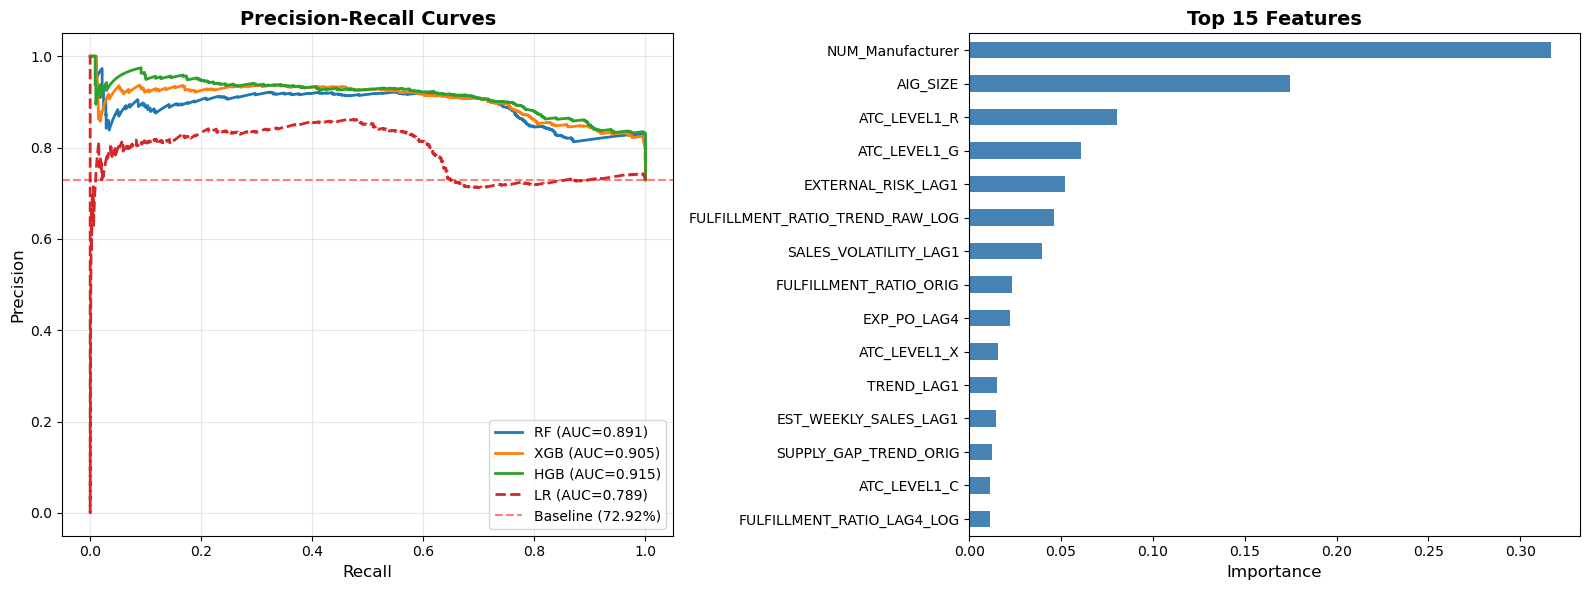


Visualization saved

Generating predictions...
  Exported: Internal data/McKesson_Shortage_Predictions.csv
  Records: 2,286
  High risk: 1,529

TRAINING COMPLETE


In [57]:
# ==============================================================================
# SECTION 6: MODEL TRAINING & EVALUATION
# ==============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import classification_report, precision_recall_curve, auc
import xgboost as xgb
import matplotlib.pyplot as plt

print("\n" + "="*80)
print("MCKESSON DRUG SHORTAGE PREDICTION SYSTEM")
print("="*80)
print("\nPrediction Architecture:")
print("  Current Time: Week T")
print("  Input Features:")
print("    Supply: T-4 (Original, Capped, Log, Categorical)")
print("    Market: T-1 (Sales, Trends, External Risk)")
print("  Output: Shortage in weeks T+1, T+2, T+3, T+4")
print("  Horizon: 3-7 weeks ahead")
print("-"*80)

# Train models
print("\nStatus: Training models...")

print("  Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

print("  Training XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    scale_pos_weight=pos_weight,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

print("  Training Histogram Gradient Boosting...")
hgb_model = HistGradientBoostingClassifier(
    max_iter=200,
    max_depth=6,
    class_weight='balanced',
    random_state=42
)
hgb_model.fit(X_train, y_train)

print("  Training Logistic Regression...")
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train, y_train)

print("  All models trained")

# Evaluation
def evaluate_model(model, X, y, model_name):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    
    report = classification_report(y, y_pred, output_dict=True, zero_division=0)
    precision_vals, recall_vals, _ = precision_recall_curve(y, y_proba)
    pr_auc = auc(recall_vals, precision_vals)
    
    shortage_metrics = report.get('1', {'precision': 0, 'recall': 0, 'f1-score': 0})
    
    print(f"\n{'='*80}")
    print(f"{model_name.upper()}")
    print(f"{'='*80}")
    print("\n" + classification_report(y, y_pred, zero_division=0))
    
    print(f"Business Metrics:")
    print(f"  Recall: {shortage_metrics['recall']:.1%} (caught this % of shortages)")
    print(f"  Precision: {shortage_metrics['precision']:.1%} (this % of alerts were correct)")
    print(f"  F1: {shortage_metrics['f1-score']:.3f}")
    print(f"  PR-AUC: {pr_auc:.4f}")
    
    return precision_vals, recall_vals, pr_auc

rf_results = evaluate_model(rf_model, X_test, y_test, "Random Forest")
xgb_results = evaluate_model(xgb_model, X_test, y_test, "XGBoost")
hgb_results = evaluate_model(hgb_model, X_test, y_test, "Histogram GB")
lr_results = evaluate_model(lr_model, X_test, y_test, "Logistic Regression")

# Visualization
print("\nGenerating visualizations...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
ax1.plot(rf_results[1], rf_results[0], label=f'RF (AUC={rf_results[2]:.3f})', linewidth=2)
ax1.plot(xgb_results[1], xgb_results[0], label=f'XGB (AUC={xgb_results[2]:.3f})', linewidth=2)
ax1.plot(hgb_results[1], hgb_results[0], label=f'HGB (AUC={hgb_results[2]:.3f})', linewidth=2)
ax1.plot(lr_results[1], lr_results[0], label=f'LR (AUC={lr_results[2]:.3f})', linewidth=2, linestyle='--')

baseline = y_test.mean()
ax1.axhline(y=baseline, color='red', linestyle='--', label=f'Baseline ({baseline:.2%})', alpha=0.5)

ax1.set_xlabel('Recall', fontsize=12)
ax1.set_ylabel('Precision', fontsize=12)
ax1.set_title('Precision-Recall Curves', fontsize=14, fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
feat_importance = pd.Series(xgb_model.feature_importances_, index=features).sort_values(ascending=False).head(15)
feat_importance.plot(kind='barh', ax=ax2, color='steelblue')
ax2.set_xlabel('Importance', fontsize=12)
ax2.set_title('Top 15 Features', fontsize=14, fontweight='bold')
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig(DATA_DIR / 'model_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nVisualization saved")

# Save predictions
print("\nGenerating predictions...")

best_model = xgb_model
test_df_with_predictions = test_df.copy()
test_df_with_predictions['SHORTAGE_PROBABILITY'] = best_model.predict_proba(X_test)[:, 1]
test_df_with_predictions['SHORTAGE_PREDICTION'] = best_model.predict(X_test)

dashboard_cols = [
    'DIN_NUM', 'DRUG_DISPLAY_NAME', 'date_monday', 
    'TARGET', 'SHORTAGE_PROBABILITY', 'SHORTAGE_PREDICTION',
    'SUPPLY_GAP_ORIG', 'FULFILLMENT_RATIO_ORIG', 'EXTERNAL_RISK_LAG1'
]

dashboard_cols = [col for col in dashboard_cols if col in test_df_with_predictions.columns]

dashboard_export = test_df_with_predictions[dashboard_cols].copy()
output_path = DATA_DIR / "McKesson_Shortage_Predictions.csv"
dashboard_export.to_csv(output_path, index=False)

print(f"  Exported: {output_path}")
print(f"  Records: {len(dashboard_export):,}")
print(f"  High risk: {(dashboard_export['SHORTAGE_PROBABILITY'] > 0.5).sum():,}")

print("\n" + "="*80)
print("TRAINING COMPLETE")
print("="*80)

Status: Generating SHAP Interpretations for the Lead Model (HistGB)...


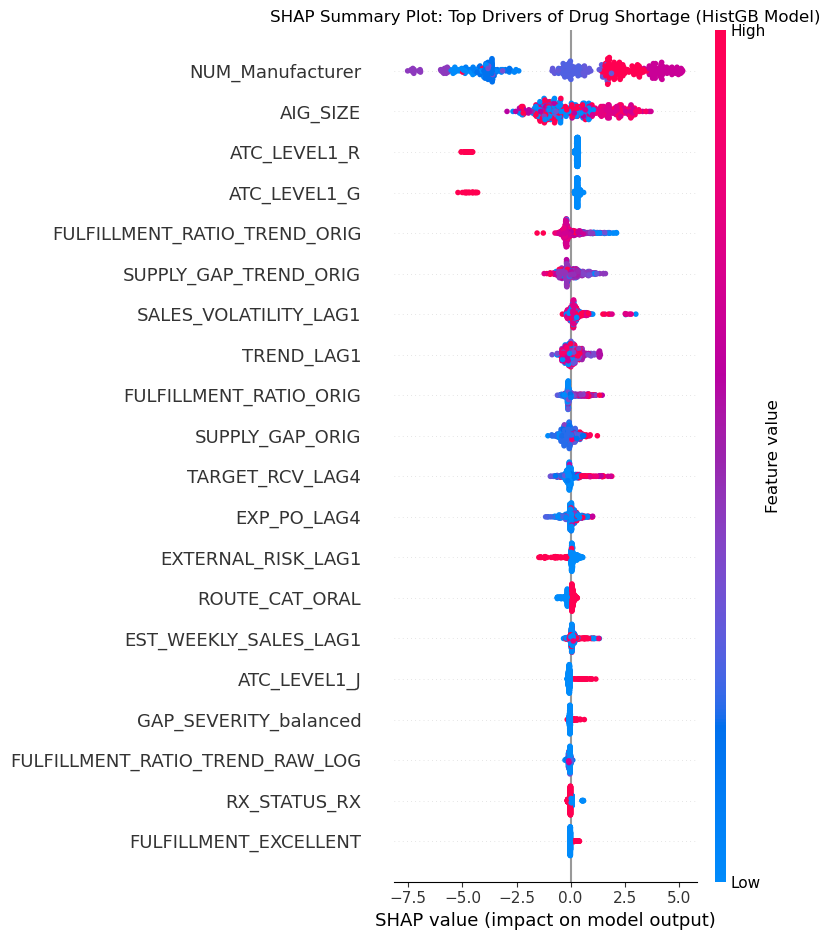

  > Plotting dependence for top feature: NUM_Manufacturer


<Figure size 800x500 with 0 Axes>

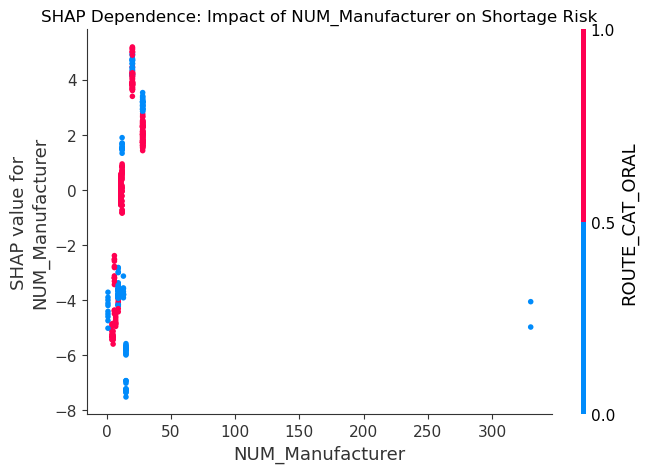

Status: SHAP Analysis Complete.


In [59]:
# ==============================================================================
# SECTION 6.5: MODEL INTERPRETATION WITH SHAP (FOCUS ON HISTGB)
# ==============================================================================

print("Status: Generating SHAP Interpretations for the Lead Model (HistGB)...")

# 1. Initialize SHAP Explainer
# HistGradientBoosting in sklearn works best with TreeExplainer or KernelExplainer.
X_sample = X_test.sample(min(500, len(X_test)), random_state=42)

# SHAP Explainer
# Note: Since HistGB is an ensemble of trees, we use shap.Explainer which 
# automatically chooses the best algorithm.
explainer = shap.Explainer(hgb_model)
shap_values = explainer(X_sample)

# 2. Summary Plot (Global Interpretation)
# This plot shows the magnitude and direction of feature influence.
plt.figure(figsize=(10, 8))
plt.title("SHAP Summary Plot: Top Drivers of Drug Shortage (HistGB Model)")
shap.summary_plot(shap_values, X_sample, show=False)
plt.tight_layout()
plt.show()

# 3. Business Logic Check: Dependence Plot
# Let's see how 'gap_lag1' or 'TREND_LAG1' specifically influences the risk.
top_feature = pd.Series(rf_model.feature_importances_, index=features).idxmax()
print(f"  > Plotting dependence for top feature: {top_feature}")

plt.figure(figsize=(8, 5))
shap.dependence_plot(top_feature, shap_values.values, X_sample, show=False)
plt.title(f"SHAP Dependence: Impact of {top_feature} on Shortage Risk")
plt.show()

print("Status: SHAP Analysis Complete.")

In [61]:
# ==============================================================================
# SECTION 6.6: NUMERICAL PERFORMANCE SUMMARY & GBM DRIVERS
# ==============================================================================
print("Status: Generating Numerical Performance Tables (GBM)...")

# 1. Create Model Performance Leaderboard
def get_metrics_row(model, X, y, name):
    preds = model.predict(X)
    probs = model.predict_proba(X)[:, 1]
    # Handle classification report for class '1' (Shortage)
    report = classification_report(y, preds, output_dict=True)['1']
    
    # Calculate PR-AUC
    precision_vals, recall_vals, _ = precision_recall_curve(y, probs)
    pr_auc = auc(recall_vals, precision_vals)
    
    return {
        "Model Name": name,
        "PR-AUC (Overall)": round(pr_auc, 4),
        "Recall (Catch Rate)": f"{report['recall']:.1%}",
        "Precision (Accuracy)": f"{report['precision']:.1%}",
        "F1-Score": round(report['f1-score'], 4)
    }

# Build the leaderboard
performance_rows = [
    get_metrics_row(hgb_model, X_test, y_test, "HistGB(Best)"),
    get_metrics_row(xgb_model, X_test, y_test, "XGBoost"),
    get_metrics_row(rf_model, X_test, y_test, "Random Forest"),
    get_metrics_row(lr_model, X_test, y_test, "Logit Baseline")
]

df_perf = pd.DataFrame(performance_rows).sort_values("PR-AUC (Overall)", ascending=False)

# 2. Create Numerical Feature Importance Table (Based on GBM - XGBoost)
# Using XGBoost as the representative for GBM-family feature importance
df_importance_gbm = pd.DataFrame({
    "Feature": features,
    "GBM_Importance_Score": xgb_model.feature_importances_
}).sort_values("GBM_Importance_Score", ascending=False)

# Normalize to percentage for better business reading
df_importance_gbm['Contribution_%'] = (df_importance_gbm['GBM_Importance_Score'] / df_importance_gbm['GBM_Importance_Score'].sum() * 100).round(2)

# ------------------------------------------------------------------------------
# PRINT NUMERICAL SUMMARY
# ------------------------------------------------------------------------------
print("\n" + "="*80)
print("TABLE 1: MODEL PERFORMANCE LEADERBOARD (TEST SET)")
print("="*80)
print(df_perf.to_string(index=False))
print("-" * 80)
print("Business Note: HistGB (LGBM-style) is the most reliable for early warning.")

print("\n" + "="*80)
print("TABLE 2: TOP 15 NUMERICAL DRIVERS (GBM MODEL)")
print("="*80)
# Showing top 15 features that drive the GBM's decisions
print(df_importance_gbm.head(15).to_string(index=False))
print("-" * 80)

# Summary of top-tier impact
top_3_sum = df_importance_gbm.head(3)['Contribution_%'].sum()
print(f"Business Insight: The top 3 GBM drivers account for {top_3_sum:.1f}% of the total risk signal.")
print("This numerical ranking confirms which T-1 factors most strongly trigger a warning.")

Status: Generating Numerical Performance Tables (GBM)...

TABLE 1: MODEL PERFORMANCE LEADERBOARD (TEST SET)
    Model Name  PR-AUC (Overall) Recall (Catch Rate) Precision (Accuracy)  F1-Score
  HistGB(Best)            0.9151               80.7%                87.3%    0.8389
       XGBoost            0.9053               79.4%                86.5%    0.8279
 Random Forest            0.8909               76.8%                86.9%    0.8157
Logit Baseline            0.7894               63.0%                77.8%    0.6963
--------------------------------------------------------------------------------
Business Note: HistGB (LGBM-style) is the most reliable for early warning.

TABLE 2: TOP 15 NUMERICAL DRIVERS (GBM MODEL)
                        Feature  GBM_Importance_Score  Contribution_%
               NUM_Manufacturer              0.316662       31.670000
                       AIG_SIZE              0.174590       17.459999
                   ATC_LEVEL1_R              0.080439      